### **Sentiment Analysis with SVM**  

This notebook focuses on training and evaluating a Support Vector Machine (SVM) model for sentiment analysis using three datasets: Amazon Books Reviews, Sentiment140 and Yelp Reviews. The goal is to assess SVM’s effectiveness in classifying sentiment by exploring different preprocessing techniques, hyperparameter tuning strategies, and evaluating performance on both original and augmented datasets.  

The notebook follows a structured workflow that includes data loading, preprocessing, hyperparameter selection, training, evaluation, and model persistence. Additionally, augmented datasets are used to examine how well the model generalizes to noisy inputs, providing insight into its robustness.  

#### **1. SVM Model on Amazon Books Reviews**  
- **1.1. Loading Data**  
- **1.2. Data Preprocessing**  
- **1.3. Testing Best Model Parameters**  
- **1.4. Train Model with Best Parameters**  
- **1.5. Model Evaluation**  
- **1.6. Model Evaluation on Augmented Data**  
- **1.7. Save Model**  

#### **2. SVM Model on Sentiment140**  
- **2.1. Loading Data**  
- **2.2. Data Preprocessing**  
- **2.3. Testing Best Model Parameters**  
- **2.4. Train Model with Best Parameters**  
- **2.5. Model Evaluation**  
- **2.6. Model Evaluation on Augmented Data**  
- **2.7. Save Model**  

#### **3. SVM Model on Yelp Reviews**  
- **3.1. Loading Data**  
- **3.2. Data Preprocessing**  
- **3.3. Testing Best Model Parameters**  
- **3.4. Train Model with Best Parameters**  
- **3.5. Model Evaluation**  
- **3.6. Model Evaluation on Augmented Data**  
- **3.7. Save Model**  


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [2]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils
from models import train_svm

In [3]:
models_output_dir = '../outputs/models/svm'
logs_output_dir = '../outputs/logs/svm'

In [4]:
# download the stopwords dict and lemmatizer for data processing
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bartek\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Bartek\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
def preprocess_data(df):
    # remove rows where 'Review' is NaN or empty
    df = df.dropna(subset=['Review']).copy()
    df = df[df['Review'].str.strip() != '']
    
    # initialize NLP tools
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    preprocessed_reviews = []

    for text in df['Review']:
        # remove special characters and URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', str(text), flags=re.MULTILINE)
        text = re.sub(r'\@\w+|\#', '', text)
        text = re.sub(r'[^A-Za-z\s]', '', text)
        text = text.lower()
        # tokenize
        tokens = word_tokenize(text)
        # remove stop words and apply lemmatization
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
        preprocessed_text = " ".join(tokens).strip()
        preprocessed_reviews.append(preprocessed_text if preprocessed_text else None)

    # replace the 'Review' column with preprocessed text
    df['Review'] = preprocessed_reviews

    # remove rows where 'Review' is empty after preprocessing
    df = df.dropna(subset=['Review'])
    df = df[df['Review'].str.strip() != '']

    return df

# 1. SVM Model on Amazon Books Reviews

## 1.1. Loading Data

In [6]:
# load the dataset
amazon_file = '../data/preprocessed/amazon.csv'
amazon_df = pd.read_csv(amazon_file, engine='python', encoding="ISO-8859-1")

In [7]:
# preview the data
amazon_df.head()

,Polarity,Review
0,0,As a Man Stinketh
1,1,MY FAVORITE!!
2,1,Epic novel
3,1,Very good source for Web Applications Development
4,1,Great fantasy


In [8]:
train_amazon_df, test_amazon_df = train_test_split(
    amazon_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=amazon_df['Polarity']
)

## 1.2. Data Preprocessing

In [9]:
# preprocess the train and test sets, test set was splitted before and will be processed separately
train_amazon_df = preprocess_data(train_amazon_df)
test_amazon_df = preprocess_data(test_amazon_df)

In [10]:
train_amazon_df.head()

,Polarity,Review
140267,0,assault blessed mother
55365,0,never got
73813,1,found shangrila
55658,1,meru puri
64958,1,great collection


In [11]:
test_amazon_df.head()

,Polarity,Review
83112,1,great
98257,0,islamophobic hardly fair
103312,1,flawed family unite
97576,1,riveting
77829,1,review rachel tear


In [12]:
DataUtils.count_reviews_by_polarity(train_amazon_df)

Number of reviews with Polarity=1: 59814
Number of reviews with Polarity=0: 59603


In [13]:
DataUtils.count_reviews_by_polarity(test_amazon_df)

Number of reviews with Polarity=1: 10556
Number of reviews with Polarity=0: 10521


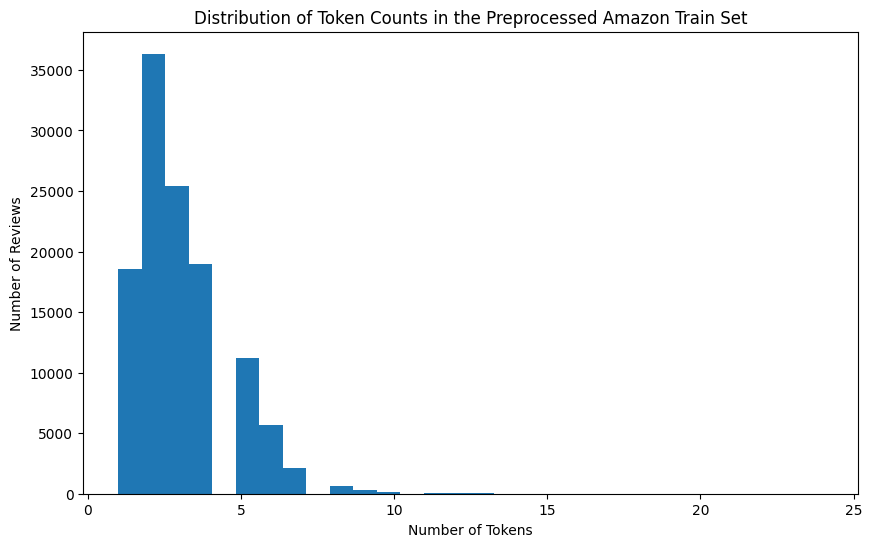

In [14]:
DataUtils.plot_token_distribution(train_amazon_df, 'Preprocessed Amazon Train Set')

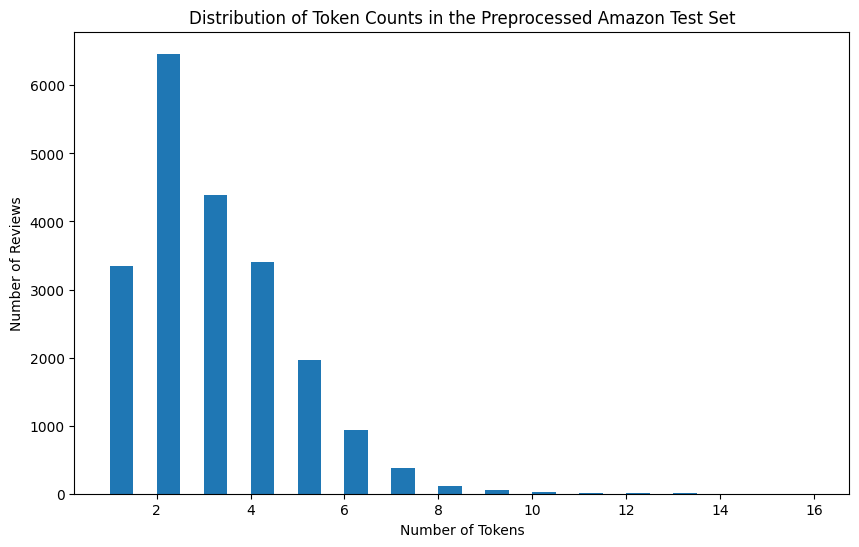

In [15]:
DataUtils.plot_token_distribution(test_amazon_df, 'Preprocessed Amazon Test Set')

In [45]:
# set parameters for the TF-IDF vectorizer
max_features = 5000 
ngram_range=(1, 2)

In [46]:
# define TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

In [47]:
# transform text into TF-IDF vectors
X_train = vectorizer.fit_transform(train_amazon_df['Review'])
X_test = vectorizer.transform(test_amazon_df['Review'])

In [48]:
# extract labels
y_train = train_amazon_df['Polarity']
y_test = test_amazon_df['Polarity']

In [49]:
# display dimensions of the feature matrices
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (119415, 5000)
X_test shape: (21076, 5000)


## 1.3 Testing Best Model Parameters

In [50]:
# setting parameters for the SVM model
kernel = 'linear' 
C = 1.0  

In [51]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [52]:
svm_model = SVC(kernel=kernel, C=C, random_state=42)

In [53]:
cv_results = cross_val_score(svm_model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)

In [54]:
mean_accuracy = cv_results.mean()
std_accuracy = cv_results.std()

In [55]:
# display cross-validation accuracy results
print("\nCross-Validation Accuracy (5-Fold):")
print(f"Mean Accuracy: {mean_accuracy:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7923
Standard Deviation: 0.0037


### 1.3.1. Testing Parameters

| **Kernel** | **C**   | **TF-IDF max_features** | **N-gram range** |
|--------------------|---------|--------------------------|-------------------|
| rbf                | 1.0     | 5000                     | (1, 1)           |
| rbf                | 10.0    | 5000                     | (1, 2)           |
| rbf                | 100.0   | 5000                     | (1, 3)           |
| poly               | 1.0     | 5000                     | (1, 1)           |
| poly               | 10.0    | 5000                     | (1, 2)           |
| poly               | 100.0   | 5000                     | (1, 3)           |
| linear             | 0.01    | 5000                     | (1, 1)           |
| linear             | 0.1     | 5000                     | (1, 2)           |
| linear             | 1.0     | 5000                     | (1, 3)           |


In [61]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='rbf', C=1.0, max_features=5000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.8104
Standard Deviation: 0.0012


In [62]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='rbf', C=10.0, max_features=5000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.8032
Standard Deviation: 0.0020


In [63]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='rbf', C=100.0, max_features=5000, ngram_range=(1, 3))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.8018
Standard Deviation: 0.0025


In [64]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='poly', C=0.1, max_features=5000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7898
Standard Deviation: 0.0020


In [65]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='poly', C=10, max_features=5000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7715
Standard Deviation: 0.0024


In [66]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='poly', C=100, max_features=5000, ngram_range=(1, 3))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7583
Standard Deviation: 0.0033


In [67]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='linear', C=0.01, max_features=5000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7284
Standard Deviation: 0.0039


In [68]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='linear', C=0.1, max_features=5000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7890
Standard Deviation: 0.0022


In [69]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='linear', C=1, max_features=5000, ngram_range=(1, 3))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7915
Standard Deviation: 0.0023


In [134]:
train_svm.check_svm_model_cv(train_df=train_amazon_df, test_df=test_amazon_df, kernel='linear', C=0.1, max_features=7000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7923
Standard Deviation: 0.0019


## 1.4. Train Model with Best Parameters

In [56]:
# set parameters for the TF-IDF vectorizer
max_features = 5000 
ngram_range=(1, 1)

In [57]:
# define TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

In [58]:
# transform text into TF-IDF vectors
X_train = vectorizer.fit_transform(train_amazon_df['Review'])
X_test = vectorizer.transform(test_amazon_df['Review'])

In [59]:
# extract labels
y_train = train_amazon_df['Polarity']
y_test = test_amazon_df['Polarity']

In [60]:
kernel = 'rbf' 
C = 1.0  

In [61]:
svm_model = SVC(kernel=kernel, C=C, random_state=42)

In [62]:
cv_results = cross_val_score(svm_model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)

In [63]:
# train the SVM model on the entire training set
svm_model.fit(X_train, y_train)

SVC(random_state=42)

## 1.5. Model Evaluation

In [64]:
# predict on the test set
y_test_pred = svm_model.predict(X_test)

In [65]:
# calculate metrics for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

In [66]:
# print metrics for the test set
print("\nTest Set Metrics:")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)


Test Set Metrics:
Accuracy: 0.812488138166635
Precision: 0.8125226784384306
Recall: 0.812488138166635
F1-Score: 0.8124807926285735


In [67]:
# display a detailed classification report for the test set
print("\nClassification Report for Test Set:\n", classification_report(y_test, y_test_pred))


Classification Report for Test Set:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81     10521
           1       0.81      0.82      0.81     10555

    accuracy                           0.81     21076
   macro avg       0.81      0.81      0.81     21076
weighted avg       0.81      0.81      0.81     21076



## 1.6. Model Evaluation on Augmented Data

In [68]:
# load the augmented test sets
test_char_swap_file = '../data/preprocessed/amazon_test_char_swap.csv'
test_char_swap_df = pd.read_csv(test_char_swap_file, engine='python', encoding="ISO-8859-1")

test_embedding_file = '../data/preprocessed/amazon_test_embedding.csv'
test_embedding_df = pd.read_csv(test_embedding_file, engine='python', encoding="ISO-8859-1")

test_eda = '../data/preprocessed/amazon_test_eda.csv'
test_eda_df = pd.read_csv(test_eda, engine='python', encoding="ISO-8859-1")

In [69]:
# preprocess the augmented test sets
test_char_swap_df = preprocess_data(test_char_swap_df)
test_embedding_df = preprocess_data(test_embedding_df)
test_eda_df = preprocess_data(test_eda_df)

In [70]:
# transform text into TF-IDF vectors
X_test_char_swap = vectorizer.transform(test_char_swap_df['Review'])
X_test_embedding = vectorizer.transform(test_embedding_df['Review'])
X_test_eda = vectorizer.transform(test_eda_df['Review'])

In [71]:
# extract labels
y_test_char_swap = test_char_swap_df['Polarity']
y_test_embedding = test_embedding_df['Polarity']
y_test_eda = test_eda_df['Polarity']

In [72]:
train_svm.evaluate_svm(svm_model, X_test_char_swap, y_test_char_swap)


Test Set Metrics:
Accuracy: 0.7216
Precision: 0.7261
Recall: 0.7216
F1-Score: 0.7202

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.69      0.79      0.74     10551
           1       0.76      0.65      0.70     10568

    accuracy                           0.72     21119
   macro avg       0.73      0.72      0.72     21119
weighted avg       0.73      0.72      0.72     21119



In [73]:
train_svm.evaluate_svm(svm_model, X_test_embedding, y_test_embedding)


Test Set Metrics:
Accuracy: 0.7441
Precision: 0.7451
Recall: 0.7441
F1-Score: 0.7439

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.73      0.78      0.75     10540
           1       0.76      0.71      0.74     10560

    accuracy                           0.74     21100
   macro avg       0.75      0.74      0.74     21100
weighted avg       0.75      0.74      0.74     21100



In [74]:
train_svm.evaluate_svm(svm_model, X_test_eda, y_test_eda)


Test Set Metrics:
Accuracy: 0.7807
Precision: 0.7809
Recall: 0.7807
F1-Score: 0.7806

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.77      0.79      0.78     10458
           1       0.79      0.77      0.78     10497

    accuracy                           0.78     20955
   macro avg       0.78      0.78      0.78     20955
weighted avg       0.78      0.78      0.78     20955



## 1.7. Save Model

In [75]:
train_svm.save_svm_model_and_vectorizer(svm_model, vectorizer, models_output_dir, 'amazon')

Model saved to ../outputs/models/svm\amazon_svm_model.joblib
Vectorizer saved to ../outputs/models/svm\amazon_svm_vectorizer.joblib


In [76]:
train_svm.save_classification_report(y_test, y_test_pred, logs_output_dir, 'amazon_test')

Classification report saved to ../outputs/logs/svm\amazon_test_svm_classification_report.txt


# 2. SVM Model on Sentiment140

## 2.1. Loading Data

In [17]:
# load the dataset
sentiment140_file = '../data/preprocessed/sentiment140.csv'
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', encoding="ISO-8859-1")

In [18]:
# preview the data
sentiment140_df.head()

,Polarity,Review
0,1,@Alicia_86 srry u get my tweet?
1,1,@jchiarelli TTS to take text Tweets to the pho...
2,1,Mmmm apple cinnomin oatmeal
3,1,@willwallaceii thanks man. the truth can be fu...
4,1,RAIN The plants and trees are happy ^~^


In [19]:
train_sentiment140_df, test_sentiment140_df = train_test_split(
    sentiment140_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=sentiment140_df['Polarity']
)

## 2.2. Data Preprocessing

In [20]:
# preprocess the train and test sets, test set was splitted before and will be processed separately
train_sentiment140_df = preprocess_data(train_sentiment140_df)
test_sentiment140_df = preprocess_data(test_sentiment140_df)

In [21]:
train_sentiment140_df.head()

,Polarity,Review
308644,0,want sweet sour bbq sauce chipc
58060,1,love forget artist ipod rediscover like hallel...
190573,1,going get haircut check crossroad vintage stor...
163792,0,pant aint put quotskiquot end surname youll pr...
193398,1,wondered slow start first half episode like di...


In [22]:
test_sentiment140_df.head()

,Polarity,Review
216920,0,live tweet streaming sytycd miss dena lisa
221592,0,ahh ok enjoy ill miss
122046,1,good agent good luck good sense avoid decent hell
47617,0,think much coffee attempt sleep barbri today
8011,0,hecc weve left x love everyone


In [23]:
DataUtils.count_reviews_by_polarity(train_sentiment140_df)

Number of reviews with Polarity=1: 135307
Number of reviews with Polarity=0: 135402


In [24]:
DataUtils.count_reviews_by_polarity(test_sentiment140_df)

Number of reviews with Polarity=1: 23873
Number of reviews with Polarity=0: 23887


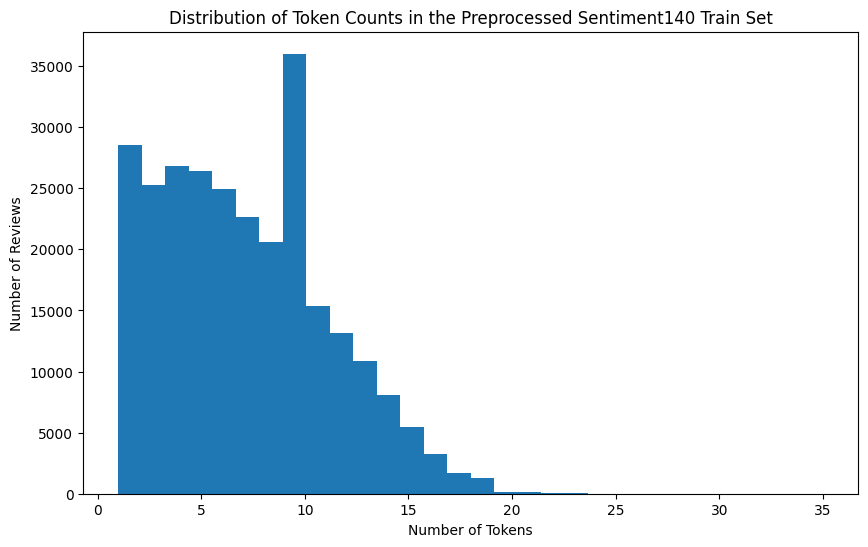

In [25]:
DataUtils.plot_token_distribution(train_sentiment140_df, 'Preprocessed Sentiment140 Train Set')

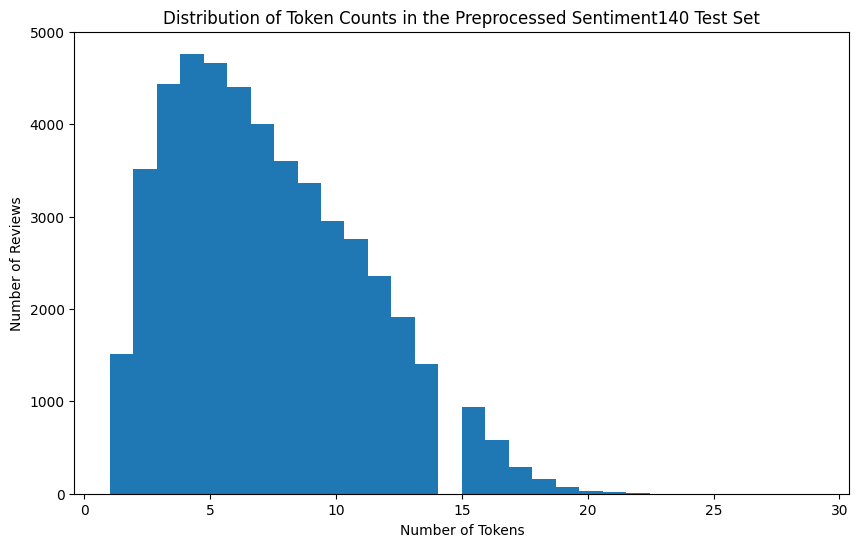

In [26]:
DataUtils.plot_token_distribution(test_sentiment140_df, 'Preprocessed Sentiment140 Test Set')

In [110]:
# set parameters for the TF-IDF vectorizer
max_features = 5000 
ngram_range=(1, 2)

In [111]:
# define TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

In [112]:
# transform text into TF-IDF vectors
X_train = vectorizer.fit_transform(train_sentiment140_df['Review'])
X_test = vectorizer.transform(test_sentiment140_df['Review'])

In [113]:
# extract labels
y_train = train_sentiment140_df['Polarity']
y_test = test_sentiment140_df['Polarity']

In [114]:
# display dimensions of the feature matrices
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (270709, 5000)
X_test shape: (47760, 5000)


## 2.3 Testing Best Model Parameters

In [115]:
# setting parameters for the SVM model
kernel = 'linear' 
C = 1.0  

In [87]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [116]:
svm_model = SVC(kernel=kernel, C=C, random_state=42)

In [89]:
cv_results = cross_val_score(svm_model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)

In [90]:
mean_accuracy = cv_results.mean()
std_accuracy = cv_results.std()

In [91]:
# display cross-validation accuracy results
print("\nCross-Validation Accuracy (5-Fold):")
print(f"Mean Accuracy: {mean_accuracy:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7731
Standard Deviation: 0.0008


### 2.3.1. Testing Parameters

| **Kernel** | **C**   | **TF-IDF max_features** | **N-gram range** |
|--------------------|---------|--------------------------|-------------------|
| rbf                | 1.0     | 5000                     | (1, 1)           |
| rbf                | 10.0    | 5000                     | (1, 2)           |
| rbf                | 100.0   | 5000                     | (1, 3)           |
| poly               | 1.0     | 5000                     | (1, 1)           |
| poly               | 10.0    | 5000                     | (1, 2)           |
| poly               | 100.0   | 5000                     | (1, 3)           |
| linear             | 0.01    | 5000                     | (1, 1)           |
| linear             | 0.1     | 5000                     | (1, 2)           |
| linear             | 1.0     | 5000                     | (1, 3)           |


In [92]:
train_svm.check_svm_model_cv(train_df=train_sentiment140_df, test_df=test_sentiment140_df, kernel='rbf', C=1.0, max_features=5000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7796
Standard Deviation: 0.0005


In [95]:
train_svm.check_svm_model_cv(train_df=train_sentiment140_df, test_df=test_sentiment140_df, kernel='poly', C=0.1, max_features=5000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7631
Standard Deviation: 0.0017


In [97]:
train_svm.check_svm_model_cv(train_df=train_sentiment140_df, test_df=test_sentiment140_df, kernel='linear', C=0.01, max_features=5000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7490
Standard Deviation: 0.0012


In [98]:
train_svm.check_svm_model_cv(train_df=train_sentiment140_df, test_df=test_sentiment140_df, kernel='linear', C=0.1, max_features=5000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7713
Standard Deviation: 0.0015


In [99]:
train_svm.check_svm_model_cv(train_df=train_sentiment140_df, test_df=test_sentiment140_df, kernel='linear', C=1, max_features=5000, ngram_range=(1, 3))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7731
Standard Deviation: 0.0009


In [100]:
train_svm.check_svm_model_cv(train_df=train_sentiment140_df, test_df=test_sentiment140_df, kernel='linear', C=1, max_features=7000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7760
Standard Deviation: 0.0013


In [133]:
train_svm.check_svm_model_cv(train_df=train_sentiment140_df, test_df=test_sentiment140_df, kernel='linear', C=2, max_features=7000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7753
Standard Deviation: 0.0011


## 2.4. Train Model with Best Parameters

In [117]:
# best found parameters regarding the training time are the same as set before
svm_model = SVC(kernel=kernel, C=C, random_state=42)

In [118]:
# train the SVM model on the entire training set
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

## 2.5. Model Evaluation

In [119]:
# predict on the test set
y_test_pred = svm_model.predict(X_test)

In [120]:
# calculate metrics for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

In [121]:
# print metrics for the test set
print("\nTest Set Metrics:")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)


Test Set Metrics:
Accuracy: 0.7744137353433835
Precision: 0.7756712116962885
Recall: 0.7744137353433835
F1-Score: 0.7741593289458805


In [122]:
# display a detailed classification report for the test set
print("\nClassification Report for Test Set:\n", classification_report(y_test, y_test_pred))


Classification Report for Test Set:
               precision    recall  f1-score   support

           0       0.79      0.74      0.77     23887
           1       0.76      0.81      0.78     23873

    accuracy                           0.77     47760
   macro avg       0.78      0.77      0.77     47760
weighted avg       0.78      0.77      0.77     47760



## 2.6. Model Evaluation on Augmented Data

In [123]:
# load the augmented test sets
test_char_swap_file = '../data/preprocessed/sentiment140_test_char_swap.csv'
test_char_swap_df = pd.read_csv(test_char_swap_file, engine='python', encoding="ISO-8859-1")

test_embedding_file = '../data/preprocessed/sentiment140_test_embedding.csv'
test_embedding_df = pd.read_csv(test_embedding_file, engine='python', encoding="ISO-8859-1")

test_eda = '../data/preprocessed/sentiment140_test_eda.csv'
test_eda_df = pd.read_csv(test_eda, engine='python', encoding="ISO-8859-1")

In [124]:
# preprocess the augmented test sets
test_char_swap_df = preprocess_data(test_char_swap_df)
test_embedding_df = preprocess_data(test_embedding_df)
test_eda_df = preprocess_data(test_eda_df)

In [125]:
# transform text into TF-IDF vectors
X_test_char_swap = vectorizer.transform(test_char_swap_df['Review'])
X_test_embedding = vectorizer.transform(test_embedding_df['Review'])
X_test_eda = vectorizer.transform(test_eda_df['Review'])

In [126]:
# extract labels
y_test_char_swap = test_char_swap_df['Polarity']
y_test_embedding = test_embedding_df['Polarity']
y_test_eda = test_eda_df['Polarity']

In [127]:
train_svm.evaluate_svm(svm_model, X_test_char_swap, y_test_char_swap)


Test Set Metrics:
Accuracy: 0.7460
Precision: 0.7503
Recall: 0.7460
F1-Score: 0.7449

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.78      0.68      0.73     23896
           1       0.72      0.81      0.76     23892

    accuracy                           0.75     47788
   macro avg       0.75      0.75      0.74     47788
weighted avg       0.75      0.75      0.74     47788



In [128]:
train_svm.evaluate_svm(svm_model, X_test_embedding, y_test_embedding)


Test Set Metrics:
Accuracy: 0.7388
Precision: 0.7433
Recall: 0.7388
F1-Score: 0.7376

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.78      0.67      0.72     23896
           1       0.71      0.81      0.76     23885

    accuracy                           0.74     47781
   macro avg       0.74      0.74      0.74     47781
weighted avg       0.74      0.74      0.74     47781



In [129]:
train_svm.evaluate_svm(svm_model, X_test_eda, y_test_eda)


Test Set Metrics:
Accuracy: 0.7581
Precision: 0.7605
Recall: 0.7581
F1-Score: 0.7575

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.79      0.71      0.75     23837
           1       0.74      0.81      0.77     23795

    accuracy                           0.76     47632
   macro avg       0.76      0.76      0.76     47632
weighted avg       0.76      0.76      0.76     47632



## 2.7 Save Model

In [130]:
train_svm.save_svm_model_and_vectorizer(svm_model, vectorizer, models_output_dir, 'sentiment140')

Model saved to ../outputs/models/svm\sentiment140_svm_model.joblib
Vectorizer saved to ../outputs/models/svm\sentiment140_svm_vectorizer.joblib


In [131]:
train_svm.save_classification_report(y_test, y_test_pred, logs_output_dir, 'sentiment140_test')

Classification report saved to ../outputs/logs/svm\sentiment140_test_svm_classification_report.txt


# 3. SVM Model on Yelp Reviews

## 3.1. Loading Data

In [27]:
# load the dataset
yelp_file = '../data/preprocessed/yelp.csv'
yelp_df = pd.read_csv(yelp_file, engine='python', encoding="ISO-8859-1")

In [28]:
# preview the data
yelp_df.head()

,Polarity,Review
0,0,The food was pretty good but the server was so...
1,0,Horrible manager! She told us we only needed t...
2,1,I Love the Black Bean Burger. So much so I cam...
3,0,Off the beaten path and you can either park yo...
4,1,"Awesome NYC pizza, my second favorite NYC styl..."


In [29]:
train_yelp_df, test_yelp_df = train_test_split(
    yelp_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=yelp_df['Polarity']
)

## 3.2. Data Preprocessing

In [30]:
# preprocess the train and test sets, test set was splitted before and will be processed separately
train_yelp_df = preprocess_data(train_yelp_df)
test_yelp_df = preprocess_data(test_yelp_df)

In [31]:
train_yelp_df.head()

,Polarity,Review
76963,1,love illy coffee smooooooooothnnhad strawberry...
63578,1,im maid honor friend wedding plan changed last...
111721,0,place dirty table floor counter drink stationn...
68247,1,taiwanchinese restaurant negative thing smell ...
56678,0,every single time come post office im inside s...


In [32]:
test_yelp_df.head()

,Polarity,Review
92403,0,came last week sandwich promotion horrible exp...
53204,1,placed order delivery received minute bad plus...
48450,1,heavenly brunch everrrrrrrrr sophias cool arti...
2581,0,place awful completely unprofessional never bu...
6021,1,come finishing result satisfied new cut servic...


In [33]:
DataUtils.count_reviews_by_polarity(train_yelp_df)

Number of reviews with Polarity=1: 47599
Number of reviews with Polarity=0: 47596


In [34]:
DataUtils.count_reviews_by_polarity(test_yelp_df)

Number of reviews with Polarity=1: 8400
Number of reviews with Polarity=0: 8399


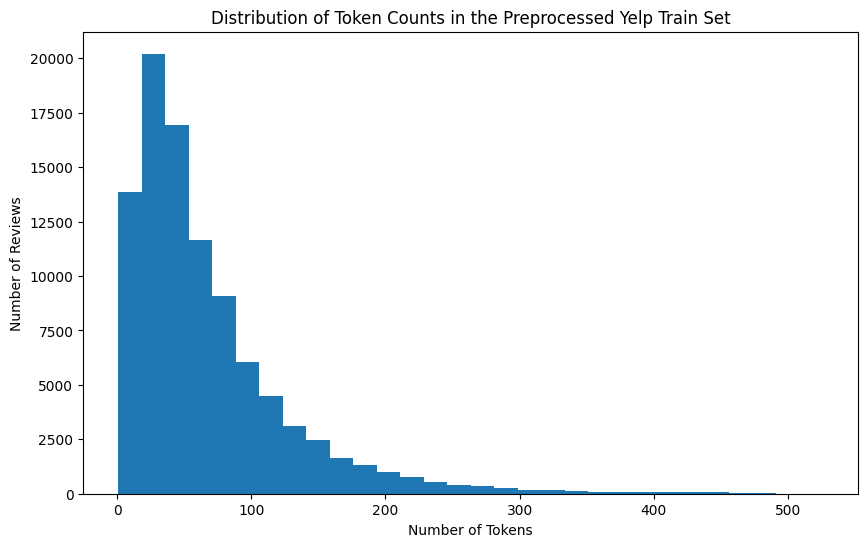

In [35]:
DataUtils.plot_token_distribution(train_yelp_df, 'Preprocessed Yelp Train Set')

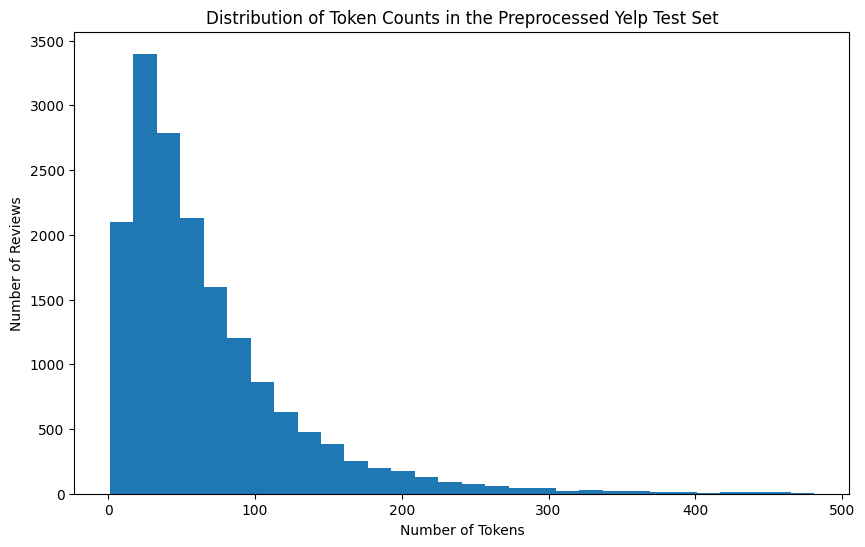

In [36]:
DataUtils.plot_token_distribution(test_yelp_df, 'Preprocessed Yelp Test Set')

In [142]:
# set parameters for the TF-IDF vectorizer
max_features = 7000 
ngram_range=(1, 2)

In [143]:
# define TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

In [144]:
# transform text into TF-IDF vectors
X_train = vectorizer.fit_transform(train_yelp_df['Review'])
X_test = vectorizer.transform(test_yelp_df['Review'])

In [145]:
# extract labels
y_train = train_yelp_df['Polarity']
y_test = test_yelp_df['Polarity']

In [146]:
# display dimensions of the feature matrices
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (95195, 7000)
X_test shape: (16799, 7000)


## 3.3 Testing Best Model Parameters

In [147]:
# setting parameters for the SVM model
kernel = 'linear' 
C = 1.0  

In [117]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [148]:
svm_model = SVC(kernel=kernel, C=C, random_state=42)

In [119]:
cv_results = cross_val_score(svm_model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)

In [120]:
mean_accuracy = cv_results.mean()
std_accuracy = cv_results.std()

In [121]:
# display cross-validation accuracy results
print("\nCross-Validation Accuracy (5-Fold):")
print(f"Mean Accuracy: {mean_accuracy:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.9224
Standard Deviation: 0.0015


### 3.3.1. Testing Parameters

| **Kernel** | **C**   | **TF-IDF max_features** | **N-gram range** |
|--------------------|---------|--------------------------|-------------------|
| rbf                | 1.0     | 7000                     | (1, 1)           |
| rbf                | 10.0    | 7000                     | (1, 2)           |
| rbf                | 100.0   | 7000                     | (1, 3)           |
| poly               | 1.0     | 7000                     | (1, 1)           |
| poly               | 10.0    | 7000                     | (1, 2)           |
| poly               | 100.0   | 7000                     | (1, 3)           |
| linear             | 0.01    | 7000                     | (1, 1)           |
| linear             | 0.1     | 7000                     | (1, 2)           |
| linear             | 1.0     | 7000                     | (1, 3)           |


In [122]:
train_svm.check_svm_model_cv(train_df=train_yelp_df, test_df=test_yelp_df, kernel='rbf', C=1.0, max_features=7000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.9199
Standard Deviation: 0.0019


In [129]:
train_svm.check_svm_model_cv(train_df=train_yelp_df, test_df=test_yelp_df, kernel='rbf', C=10.0, max_features=7000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.9258
Standard Deviation: 0.0016


In [123]:
train_svm.check_svm_model_cv(train_df=train_yelp_df, test_df=test_yelp_df, kernel='poly', C=0.1, max_features=7000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.7841
Standard Deviation: 0.0109


In [130]:
train_svm.check_svm_model_cv(train_df=train_yelp_df, test_df=test_yelp_df, kernel='poly', C=10, max_features=7000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.9002
Standard Deviation: 0.0017


In [124]:
train_svm.check_svm_model_cv(train_df=train_yelp_df, test_df=test_yelp_df, kernel='linear', C=0.01, max_features=7000, ngram_range=(1, 1))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.8883
Standard Deviation: 0.0020


In [131]:
train_svm.check_svm_model_cv(train_df=train_yelp_df, test_df=test_yelp_df, kernel='linear', C=0.1, max_features=7000, ngram_range=(1, 2))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.9172
Standard Deviation: 0.0016


In [132]:
train_svm.check_svm_model_cv(train_df=train_yelp_df, test_df=test_yelp_df, kernel='linear', C=1, max_features=7000, ngram_range=(1, 3))


Cross-Validation Accuracy (5-Fold):
Mean Accuracy: 0.9227
Standard Deviation: 0.0015


## 3.4. Train Model with Best Parameters

In [149]:
# best found parameters regarding the training time are the same as set before
svm_model = SVC(kernel=kernel, C=C, random_state=42)

In [150]:
# train the SVM model on the entire training set
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

## 3.5. Model Evaluation

In [151]:
# predict on the test set
y_test_pred = svm_model.predict(X_test)

In [152]:
# calculate metrics for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

In [153]:
# print metrics for the test set
print("\nTest Set Metrics:")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)


Test Set Metrics:
Accuracy: 0.9242216798618965
Precision: 0.9242282103217907
Recall: 0.9242216798618965
F1-Score: 0.9242213785801993


In [154]:
# display a detailed classification report for the test set
print("\nClassification Report for Test Set:\n", classification_report(y_test, y_test_pred))


Classification Report for Test Set:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92      8399
           1       0.92      0.93      0.92      8400

    accuracy                           0.92     16799
   macro avg       0.92      0.92      0.92     16799
weighted avg       0.92      0.92      0.92     16799



## 3.6. Model Evaluation on Augmented Data

In [155]:
# load the augmented test sets
test_char_swap_file = '../data/preprocessed/yelp_test_char_swap.csv'
test_char_swap_df = pd.read_csv(test_char_swap_file, engine='python', encoding="ISO-8859-1")

test_transform_file = '../data/preprocessed/yelp_test_transform.csv'
test_transform_df = pd.read_csv(test_transform_file, engine='python', encoding="ISO-8859-1")

test_combined_file = '../data/preprocessed/yelp_test_combined.csv'
test_combined_df = pd.read_csv(test_combined_file, engine='python', encoding="ISO-8859-1")

In [156]:
# preprocess the augmented test sets
test_char_swap_df = preprocess_data(test_char_swap_df)
test_transform_df = preprocess_data(test_transform_df)
test_combined_df = preprocess_data(test_combined_df)

In [157]:
# transform text into TF-IDF vectors
X_test_char_swap = vectorizer.transform(test_char_swap_df['Review'])
X_test_transform = vectorizer.transform(test_transform_df['Review'])
X_test_combined = vectorizer.transform(test_combined_df['Review'])

In [158]:
# extract labels
y_test_char_swap = test_char_swap_df['Polarity']
y_test_transform = test_transform_df['Polarity']
y_test_combined = test_combined_df['Polarity']

In [160]:
train_svm.evaluate_svm(svm_model, X_test_char_swap, y_test_char_swap)


Test Set Metrics:
Accuracy: 0.8537
Precision: 0.8540
Recall: 0.8537
F1-Score: 0.8537

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      8399
           1       0.86      0.84      0.85      8400

    accuracy                           0.85     16799
   macro avg       0.85      0.85      0.85     16799
weighted avg       0.85      0.85      0.85     16799



In [161]:
train_svm.evaluate_svm(svm_model, X_test_transform, y_test_transform)


Test Set Metrics:
Accuracy: 0.9127
Precision: 0.9127
Recall: 0.9127
F1-Score: 0.9127

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      8399
           1       0.91      0.91      0.91      8400

    accuracy                           0.91     16799
   macro avg       0.91      0.91      0.91     16799
weighted avg       0.91      0.91      0.91     16799



In [162]:
train_svm.evaluate_svm(svm_model, X_test_combined, y_test_combined)


Test Set Metrics:
Accuracy: 0.8392
Precision: 0.8396
Recall: 0.8392
F1-Score: 0.8391

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      8399
           1       0.85      0.82      0.84      8400

    accuracy                           0.84     16799
   macro avg       0.84      0.84      0.84     16799
weighted avg       0.84      0.84      0.84     16799



## 3.7 Save Model

In [163]:
train_svm.save_svm_model_and_vectorizer(svm_model, vectorizer, models_output_dir, 'yelp')

Model saved to ../outputs/models/svm\yelp_svm_model.joblib
Vectorizer saved to ../outputs/models/svm\yelp_svm_vectorizer.joblib


In [164]:
train_svm.save_classification_report(y_test, y_test_pred, logs_output_dir, 'yelp_test')

Classification report saved to ../outputs/logs/svm\yelp_test_svm_classification_report.txt
